## **Carlini-Wagner Attack**

In [ ]:
import tensorflow as tf
tf.random.set_seed(1)
import numpy as np
np.random.seed(1)
from tensorflow import keras
from tensorflow.keras import layers

import IPython.display
from PIL import Image
from matplotlib import cm

# simple CNN for MNIST data set
def define_model():
    inputs = tf.keras.Input(shape=(28,28,1),name='inputs')
    x = tf.keras.layers.Conv2D(32,kernel_size=3,activation='relu')(inputs)
    x = tf.keras.layers.Conv2D(64,kernel_size=3,activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(10)(x) # no softmax
    model = keras.Model(inputs,outputs)
    model.summary()
    return model


# Load and preprocess training data (MNIST)
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
train_images = train_images / 255.0
test_images = test_images / 255.0
train_labels = tf.keras.utils.to_categorical(train_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

# Define and train model
model = define_model()
model.compile(loss=keras.losses.CategoricalCrossentropy(from_logits=True),optimizer=keras.optimizers.Adam(),metrics=["accuracy"])
model.fit(train_images,train_labels, validation_data=(test_images,test_labels),batch_size=64, epochs=25) #epochs=25


# Let's look at first test image
x0 = test_images[0:1]  #(batch_size, height, width)
Image.fromarray(np.uint8(255*cm.gray(np.squeeze(x0)))).save('x0.png') #converting the tensor into an image, squeeze removes batch dim
IPython.display.Image('x0.png')

y0 = test_labels[0:1]
print('True class: % i' % np.argmax(y0))
predictions = model.predict(x0)
print('Predictive probabilities:')
with np.printoptions(precision=10, suppress=True):
    print(np.squeeze(tf.nn.softmax(predictions)))


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 146s 154ms/step - accuracy: 0.9308 - loss: 0.2261 - val_accuracy: 0.9865 - val_loss: 0.0472
Epoch 2/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 140s 149ms/step - accuracy: 0.9720 - loss: 0.0934 - val_accuracy: 0.9902 - val_loss: 0.0337
Epoch 3/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 140s 150ms/step - accuracy: 0.9769 - loss: 0.0737 - val_accuracy: 0.9894 - val_loss: 0.0311
Epoch 4/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 139s 149ms/step - accuracy: 0.9814 - loss: 0.0610 - val_accuracy: 0.9917 - val_loss: 0.0271
Epoch 5/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 140s 149ms/step - accuracy: 0.9829 - loss: 0.0563 - val_accuracy: 0.9917 - val_loss: 0.0285
Epoch 6/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 142s 149ms/step - accuracy: 0.9845 - loss: 0.0506 - val_accuracy: 0.9921 - val_loss: 0.0266
Epoch 7/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 146s 153ms/step - accuracy: 0.9850 - loss: 0.0467 - val_accuracy: 0.9928 - val_loss: 0.0258
Epoch 8/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 139s 148ms/step - accuracy: 0.9868 -

In [ ]:
#model.save('model.hp5')
model.save('model.keras')


In [ ]:
import tensorflow as tf
model = tf.keras.models.load_model("model.keras")

In [ ]:
# Load and preprocess training data (MNIST)
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
train_images = train_images / 255.0
test_images = test_images / 255.0
train_labels = tf.keras.utils.to_categorical(train_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


(1, 28, 28)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
(1, 10)
7


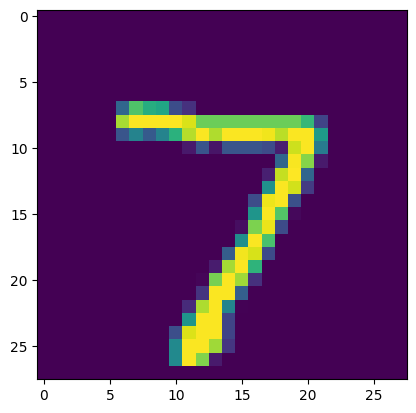

In [ ]:
#simpler way to show the image :D
import matplotlib.pyplot as plt
import numpy as np

print(test_images[0:1].shape)
plt.imshow(np.squeeze(test_images[0:1]))

prediction=model.predict(test_images[0:1])
print(prediction.shape)
print(np.argmax(prediction))

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

x0=test_images[0:1][..., np.newaxis]
y0 = test_labels[0:1]

#define a custum layer in tf for perturbation
#=========================================================================
class perturbation_layer(tf.keras.layers.Layer):

  def __init__(self, ):
    super(perturbation_layer, self).__init__()

  def build(self, input_shape):
    self.delta = self.add_weight(name="delta",
                                  shape=(28,28,1),
                                 trainable=True,
                                 initializer="zeros")

  def call(self, inputs):
     t=tf.add(inputs, self.delta)

     #squared-(L2) regularizer on new perturbation layer
     l2_reg=tf.norm(self.delta) ** 2
     self.add_loss(l2_reg)

     return tf.clip_by_value (t,clip_value_min=0, clip_value_max=1)


#defining carlini_wagner custom loss function
#==========================================================================
def carlini_wagner_loss(y_true, y_pred):

  # these values led to smaller norm
  target = 3
  k = 0
  lamd = 2

  adv_prediction_1=y_pred[:,0:target]
  adv_prediction_2=y_pred[:,target+1:]
  other_class_pred=tf.concat([adv_prediction_1,adv_prediction_2],axis=1)

  target_digit=y_pred[:,target]

  other_class=tf.reduce_max(other_class_pred, axis=1)
  loss=lamd *  tf.maximum(other_class - target_digit,-k)

  return loss

#defining adversarial network
#==========================================================================
attack_input=tf.keras.Input(shape=(28,28,1))

perturb_layer=perturbation_layer()

model.trainable = False
perturb_x =perturb_layer(attack_input)

prediction_attack=model(perturb_x ,training=False)

adv_model=tf.keras.Model(attack_input,prediction_attack)

#target_label=3
y = np.array([3])

#training the adversarial model
#==========================================================================
adv_model.compile(loss=carlini_wagner_loss,
                  optimizer=keras.optimizers.Adam())

adv_model.fit(x0,y,batch_size=1, epochs=500)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 62.6891
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 50.1335
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 67.2826
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 46.7350
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 51.7311
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 33.4114
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 46.7894
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 61.2688
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 49.2822
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 36.0623
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 17.8662
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 33.0960
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 35.3885
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 50.6140
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 59.9438
E

In [ ]:
#check the prediction
#==========================================================================
pred = adv_model.predict(x0)
print("Predicted class:", np.argmax(pred))
print("Probabilities:", tf.nn.softmax(pred).numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
Predicted class: 3
Probabilities: [[1.1740429e-09 1.8618837e-06 1.8430092e-06 9.6156418e-01 3.5856278e-08
  2.5417681e-05 4.2370140e-12 3.8360856e-02 9.3561590e-07 4.4918022e-05]]


In [ ]:
trained_delta=perturb_layer.delta.numpy()
print(trained_delta.shape)
print(np.sum(np.abs(trained_delta) >0))
print("L2 norm:", np.linalg.norm(trained_delta))
#28 * 28=784

(28, 28, 1)
749
L2 norm: 1.6532508


In [ ]:
print(adv_model.trainable_variables) #only one trainable variable: delta

[<Variable path=perturbation_layer_10/delta, shape=(28, 28, 1), dtype=float32, value=[[[ 0.00000000e+00]
  [ 0.00000000e+00]
  [ 0.00000000e+00]
  [ 0.00000000e+00]
  [ 0.00000000e+00]
  [-5.97536598e-08]
  [-2.41713195e-07]
  [ 5.26232746e-08]
  [ 1.39794392e-05]
  [-1.22114143e-04]
  [-5.85364352e-04]
  [ 4.43484496e-05]
  [ 2.24747253e-03]
  [ 1.04571721e-02]
  [ 2.85688415e-03]
  [ 4.75395378e-03]
  [ 2.31215078e-03]
  [-5.58443236e-10]
  [ 0.00000000e+00]
  [ 0.00000000e+00]
  [ 0.00000000e+00]
  [ 0.00000000e+00]
  [ 0.00000000e+00]
  [ 0.00000000e+00]
  [ 0.00000000e+00]
  [ 0.00000000e+00]
  [ 0.00000000e+00]
  [ 0.00000000e+00]]

 [[ 0.00000000e+00]
  [-2.35003750e-08]
  [ 9.64437952e-09]
  [ 2.06973112e-07]
  [-2.40502146e-07]
  [-3.61193961e-04]
  [ 6.61682886e-09]
  [ 1.19103258e-02]
  [-2.09631780e-05]
  [-9.99129005e-03]
  [-6.81296588e-05]
  [-7.97891244e-03]
  [ 8.36172112e-05]
  [ 5.01028588e-03]
  [ 2.53638979e-02]
  [ 5.21944044e-03]
  [ 1.12320686e-08]
  [ 9.6430080

# **Task 2**


**Sparse Perturbations**

**Hoyer-Square regularize**
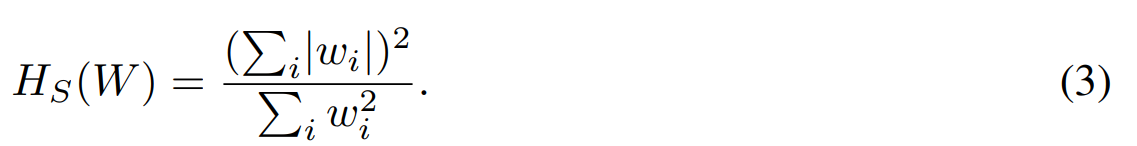

In [ ]:
#define a custum layer in tf for perturbation
#=========================================================================
class perturbation_layer_hoyer(tf.keras.layers.Layer):

  def __init__(self, ):
    super(perturbation_layer_hoyer, self).__init__()

  def build(self, input_shape):
    self.delta = self.add_weight(name="delta",
                                  shape=(28,28,1),
                                 trainable=True,
                                 initializer="zeros")
    self.epsilon= 1e-6

  def call(self, inputs):
     t=tf.add(inputs, self.delta)


     #hoyer_square regularizer
     numerator =tf.reduce_sum(tf.abs(self.delta)) ** 2
     denominator=tf.reduce_sum(tf.square(self.delta)) + self.epsilon
     hoyer_square=numerator / denominator
     self.add_loss(hoyer_square )

     return tf.clip_by_value (t,clip_value_min=0, clip_value_max=1)


In [ ]:
#defining adversarial network with Hoyer perturbation layer
#==========================================================================

attack_input=tf.keras.Input(shape=(28,28,1))

perturb_layer_hoyer=perturbation_layer_hoyer()

model.trainable = False
perturb_x =perturb_layer_hoyer(attack_input)

prediction_attack=model(perturb_x ,training=False)

adv_model_hoyer=tf.keras.Model(attack_input,prediction_attack)

#target_label=3
y = np.array([3])

#training the adversarial model
#==========================================================================
adv_model_hoyer.compile(loss=carlini_wagner_loss,
                  optimizer=keras.optimizers.Adam())

adv_model_hoyer.fit(x0,y,batch_size=1, epochs=500)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 810ms/step - loss: 66.2535
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 456.9487
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 375.1530
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 194.5871
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 205.9050
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 185.1739
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 181.0854
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 203.0154
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 171.1909
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - loss: 179.6479
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 164.2989
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - loss: 153.8180
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 149.4719
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - loss: 154.6874
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/ste

With L2 regularizer, the model is allowed to change many pixels a little bit. So it has more freedom.

With Hoyer-square, the regularizer pushes many delta values toward zero. So the attack has less freedom.

In [ ]:
delta_np=perturb_layer_hoyer.delta.numpy()
print(delta_np.shape)
print(np.sum((np.abs(delta_np) > 0))) #how many pixel changed

(28, 28, 1)
438


In [ ]:
prediction=adv_model_hoyer.predict(x0)
print(np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
7


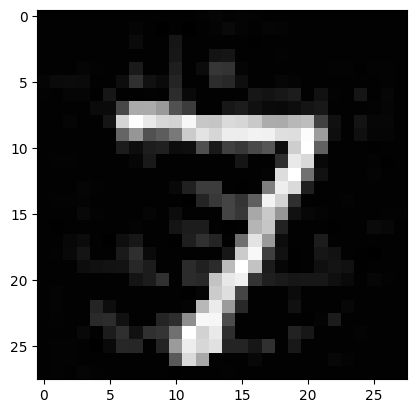

In [ ]:
adv_img = x0 + perturb_layer.delta.numpy()

plt.imshow(adv_img[0, :, :, 0], cmap="gray")